### Libraries

In [ ]:
import json
import numpy as np

import sys
import os
sys.path.append(os.path.abspath("../.."))
from scripts.GSA.fmg_gsa_utils import (
    modulus_func,
    load_data,
    perform_sensitivity_analysis,
)

from scripts.GSA.fmg_gsa_vis_utils import (
    plot_sensitivity_indices,
    read_excel_range,
    plot_Linf_grouped
)

### Load Data and Preliminary Setup

In [3]:
# Load the configuration for the FMG model parameters and data paths
HS = 20
with open(f'../../configs/{HS}HSWF_FMG_Config.json', 'r') as config_file:
    config = json.load(config_file)

file_path = config['file_path']
rows = config['rows']
cols = config['cols']
params_list = config['params_list']
GnP_list = config['GnP_list']

optimized_params_df = load_data(file_path, rows, cols, params_list)

# GnP_idx = 0, 1, 2, 3 -> 0%, 0.5%, 1%, and 1.5% GnP
GnP_idx = 0

# Assign optimized model parameters to mu
mu = np.array(optimized_params_df.iloc[GnP_idx])

# Calculate the standard deviation (sigma) as a percentage of the mean (mu)
std_fctr = 0.05
sigma = std_fctr * mu

# Calculate the bounds for the uniform distribution based on the mean (mu) and standard deviation (sigma)
upper_bound = 1/2 * (np.sqrt(12)*sigma + 2*mu)
lower_bound = 2 * mu - upper_bound

# Unified frequency range
w_freq = np.logspace(-8, 2, 100)

# Calculate the model evaluations for storage, loss, and magnitude of complex moduli using the optimized parameters
model_params = mu
Ep_model = [modulus_func(w_value, model_params, 'storage') for w_value in w_freq]
Epp_model = [modulus_func(w_value, model_params, 'loss') for w_value in w_freq]
Ecomplex_model = [modulus_func(w_value, model_params, 'complex') for w_value in w_freq]

### Perform the Sensitivity Analysis

In [4]:
# Define the sensitivity analysis problem
SA_problem = {
    'num_vars': len(params_list),
    'names': params_list,
    'bounds': np.column_stack((lower_bound, upper_bound))
}

# Number of realizations (N = 2**m)
m_min = 5
m_max = 11
step = 2
N_values = [2**i for i in range(m_min, m_max+step, step)]

# Define column names for the sensitivity indices DataFrames
column_names = params_list + [f"{param}_CI" for param in params_list] + ["freq"]

# Perform sensitivity analysis
perform_sensitivity_analysis(SA_problem, N_values, w_freq, column_names, file_path, HS, GnP_list, GnP_idx)

### Variation of Sensitivity Indices
The following code cell use `plot_sensitivity_indices` function to plot the variation of sobol sensitivity indices ($S1$ or $ST$) for moduli ($E^{\prime}$, $E^{\prime\prime}$, or $E^{*}$), given different datasets. This code can reproduce Fig. 11, Fig. S9, and Fig. S10 in the paper.

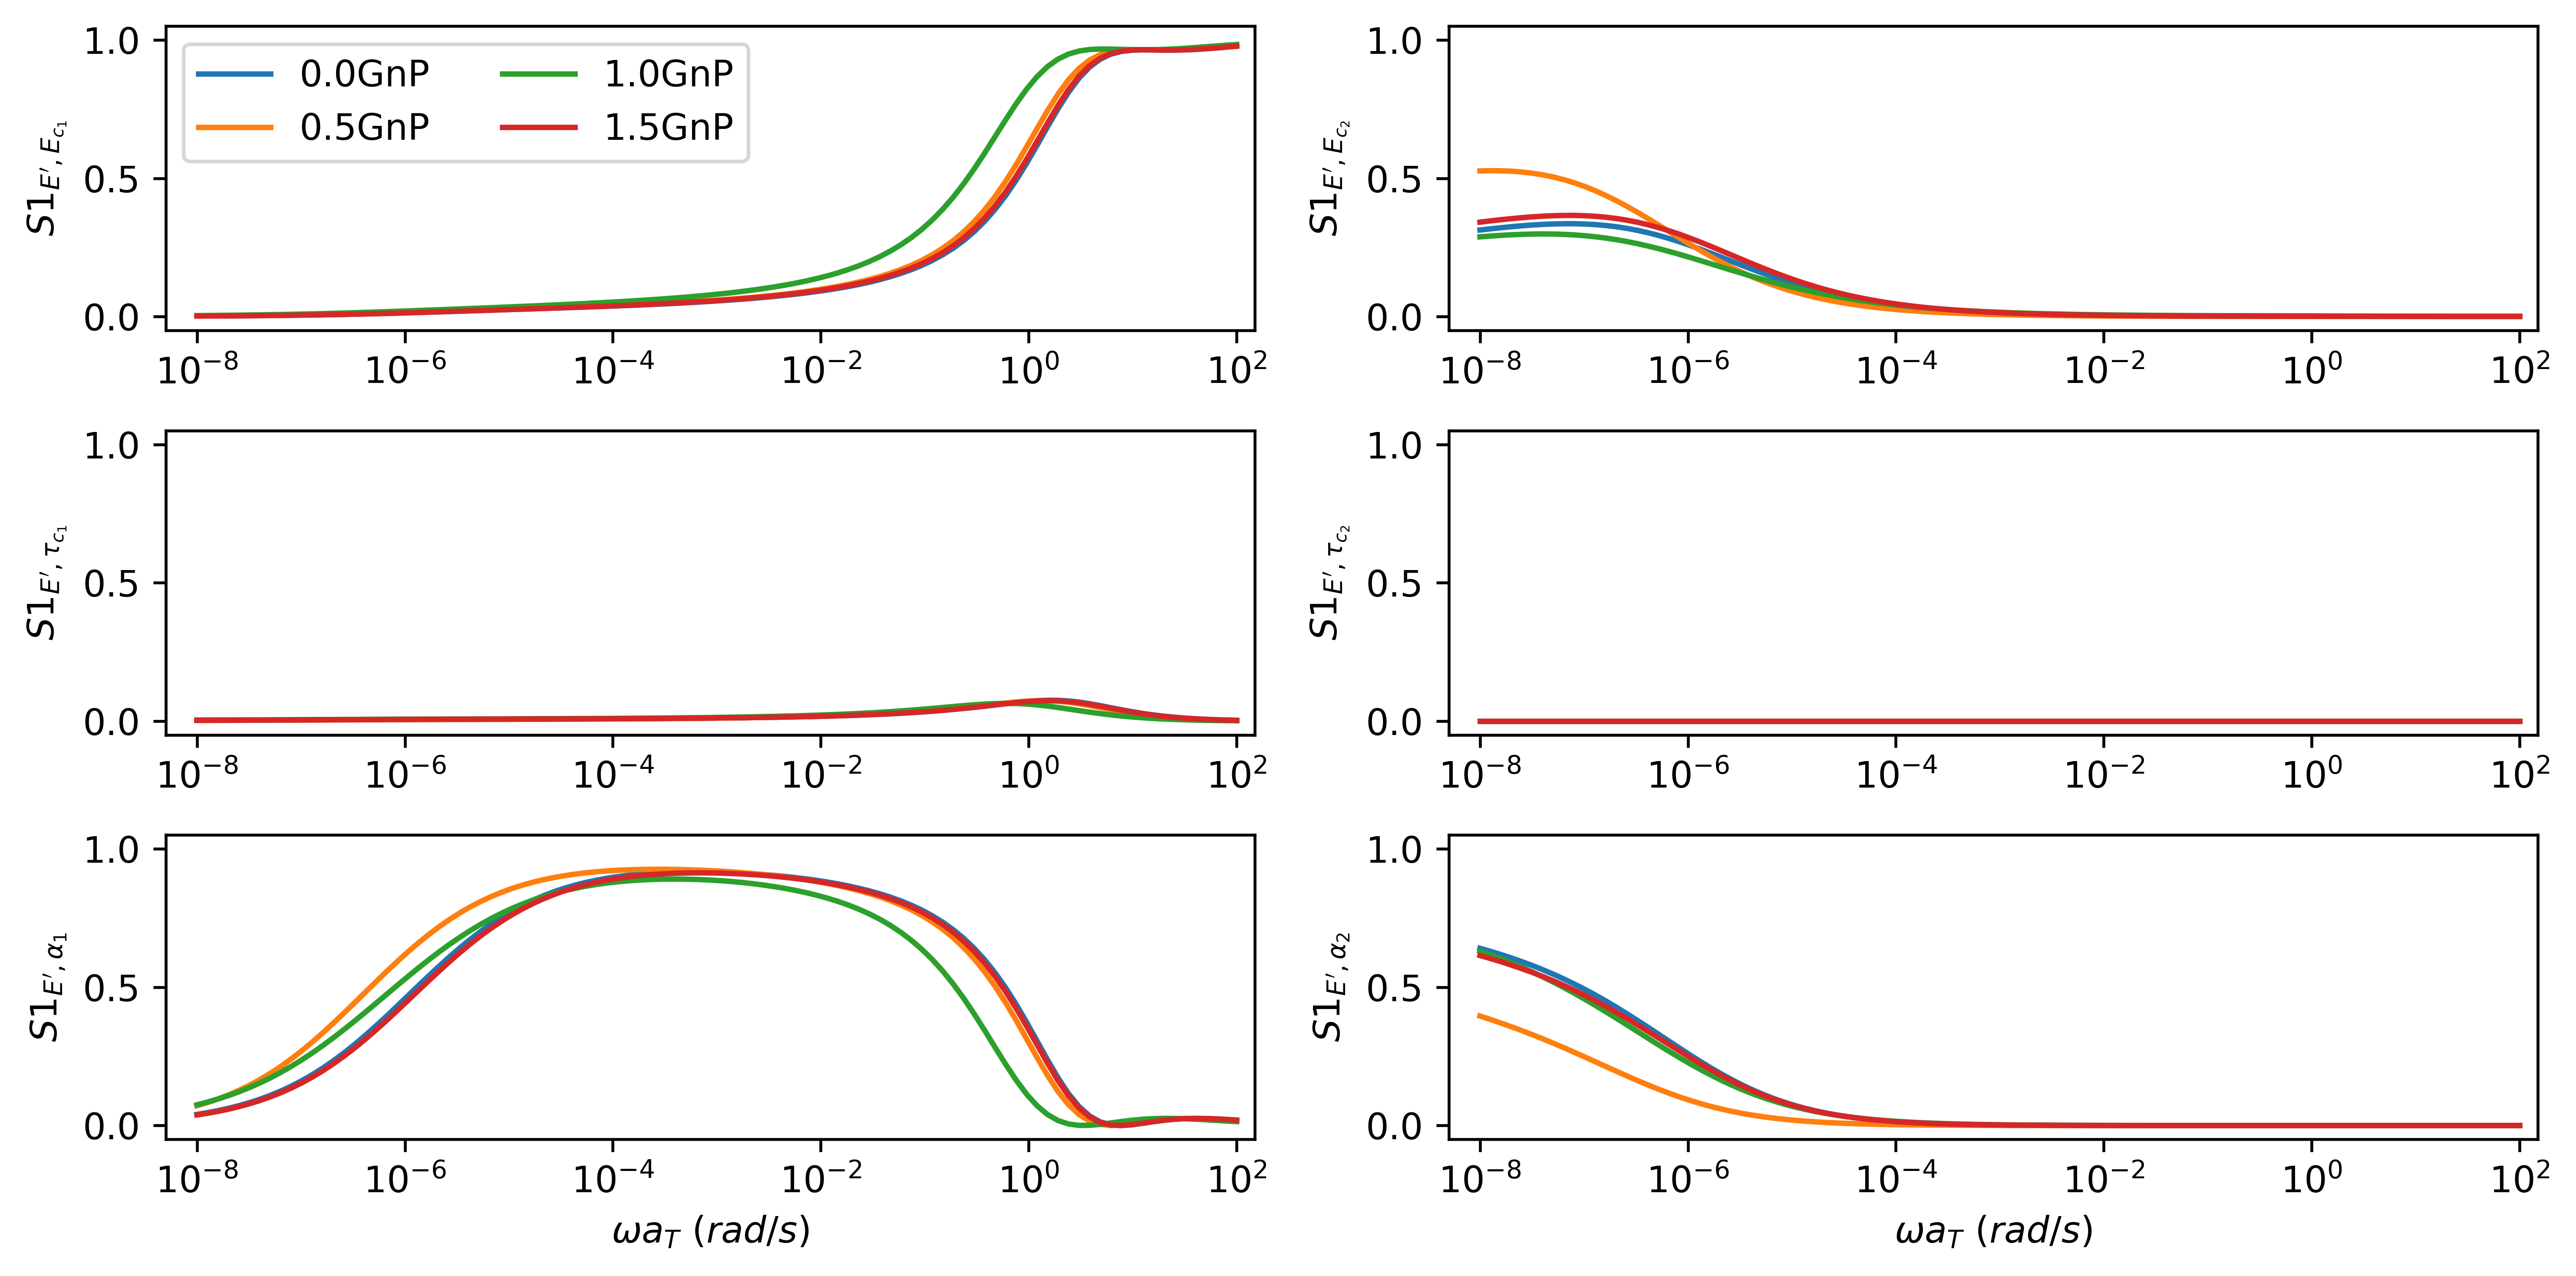

In [7]:
plot_sensitivity_indices(S='S1', E='Ep', N=N_values[-1], HS=HS, w_freq=w_freq, GnP_list=GnP_list, params_list=params_list, file_path=file_path)

### Barplot of $L_{\infty}$ of Sensitivity Indices
The following code cell use `plot_Linf_grouped` to reproduce Fig. 12 in the paper. Mean and std of $L_{\infty}$ of sensitivity indices are already calculated and stored in `GSA_FMG.xlsx`.

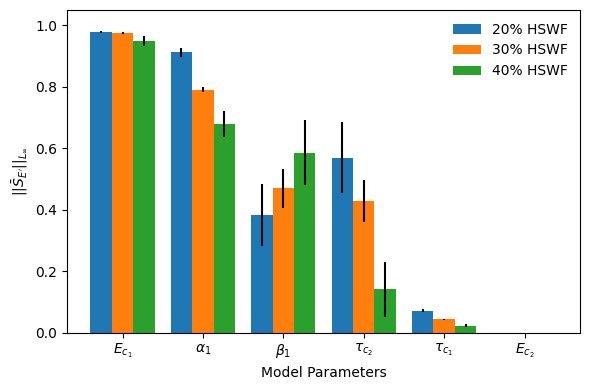

In [9]:
filename = "../../results/GSA/GSA_FMG.xlsx"

Linf_Ep_20HS  = read_excel_range(filename=filename, cell_range="C8:H9")
Linf_Ep_30HS  = read_excel_range(filename=filename, cell_range="C15:H16")
Linf_Ep_40HS  = read_excel_range(filename=filename, cell_range="C22:H23")

Linf_Epp_20HS = read_excel_range(filename=filename, cell_range="L8:Q9")
Linf_Epp_30HS = read_excel_range(filename=filename, cell_range="L15:Q16")
Linf_Epp_40HS = read_excel_range(filename=filename, cell_range="L22:Q23")

Linf_Ecomplex_20HS = read_excel_range(filename=filename, cell_range="U8:Z9")
Linf_Ecomplex_30HS = read_excel_range(filename=filename, cell_range="U15:Z16")
Linf_Ecomplex_40HS = read_excel_range(filename=filename, cell_range="U22:Z23")

Linf_Ep_mean = np.vstack([Linf_Ep_20HS[0, :],  Linf_Ep_30HS[0, :],  Linf_Ep_40HS[0, :]])
Linf_Ep_std = np.vstack([Linf_Ep_20HS[1, :],  Linf_Ep_30HS[1, :],  Linf_Ep_40HS[1, :]])

Linf_Epp_mean = np.vstack([Linf_Epp_20HS[0, :], Linf_Epp_30HS[0, :], Linf_Epp_40HS[0, :]])
Linf_Epp_std = np.vstack([Linf_Epp_20HS[1, :], Linf_Epp_30HS[1, :], Linf_Epp_40HS[1, :]])

Linf_Ecomplex_mean = np.vstack([Linf_Ecomplex_20HS[0, :], Linf_Ecomplex_30HS[0, :], Linf_Ecomplex_40HS[0, :]])
Linf_Ecomplex_std = np.vstack([Linf_Ecomplex_20HS[1, :], Linf_Ecomplex_30HS[1, :], Linf_Ecomplex_40HS[1, :]])

plot_Linf_grouped(
    Linf_Ep_mean,
    Linf_Ep_std,
    ylabel=r"$||\bar{S}_{E^{\prime}}||_{L_{\infty}}$",
    save_path="../../results/GSA/GSA_Linf_Ep"
)